# Guitar Chord Recognition — CNN Model

**University project — Machine Learning**

Pipeline: `audio -> mel-spectrogram -> CNN -> chord`

Dataset: [Guitar Chords V3](https://www.kaggle.com/datasets/fabianavinci/guitar-chords-v3)

---

### How to run
1. **Runtime -> Change runtime type -> T4 GPU** (free)
2. Run cells in order (Shift+Enter)
3. For cell 5 you'll need Kaggle credentials (see instructions there)


## 1. Install packages

In [1]:
!pip install -q librosa scikit-learn seaborn kagglehub

## 2. Imports and GPU check

In [2]:
import os
import random
import numpy as np
import librosa
import librosa.display
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, random_split
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
from pathlib import Path

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using: {device}')
if device.type == 'cuda':
    print(f'GPU: {torch.cuda.get_device_name(0)}')
else:
    print('WARNING: no GPU available, training will be slow. Go to Runtime -> Change runtime type -> T4 GPU')

Using: cuda
GPU: Tesla T4


## 3. Download dataset from Kaggle (kagglehub)

**Authentication — pick one of two options:**

**A) Easiest: Colab Secrets** (recommended)
1. Click the key icon on the left (`Secrets`)
2. Add two secrets:
   - `KAGGLE_USERNAME` -> your Kaggle username
   - `KAGGLE_KEY` -> API key (Kaggle -> Settings -> Create New API Token, open `kaggle.json` and copy `key`)
3. Enable "Notebook access" for both

**B) Upload kaggle.json** — uncomment the alternative block below

In [4]:
# --- Option A: Colab Secrets ---
from google.colab import userdata
import os


# --- Option B: upload kaggle.json (uncomment if not using Secrets) ---
# from google.colab import files
# files.upload()  # select kaggle.json
# !mkdir -p ~/.kaggle && mv kaggle.json ~/.kaggle/ && chmod 600 ~/.kaggle/kaggle.json

import kagglehub
DATASET_PATH = kagglehub.dataset_download('fabianavinci/guitar-chords-v3')
print(f'Dataset downloaded to: {DATASET_PATH}')
!ls "$DATASET_PATH"

100%|██████████| 729M/729M [00:10<00:00, 73.4MB/s]

Extracting files...


Dataset downloaded to: /root/.cache/kagglehub/datasets/fabianavinci/guitar-chords-v3/versions/1
Test  Training


## 4. Explore the dataset

In [5]:
DATA_DIR = Path(DATASET_PATH)

# Find all folders that contain .wav files (structure: .../<class>/<file>.wav)
def find_class_folders(root):
    folders = {}
    for path in root.rglob('*.wav'):
        cls = path.parent.name
        folders.setdefault(cls, []).append(path)
    return folders

class_files = find_class_folders(DATA_DIR)
print(f'Number of classes: {len(class_files)}')
for cls, paths in sorted(class_files.items()):
    print(f'  {cls}: {len(paths)} files')

CLASSES = sorted(class_files.keys())
NUM_CLASSES = len(CLASSES)
class_to_idx = {c: i for i, c in enumerate(CLASSES)}
print(f'\nClasses: {CLASSES}')

Number of classes: 8
  Am: 220 files
  Bb: 220 files
  Bdim: 220 files
  C: 220 files
  Dm: 220 files
  Em: 220 files
  F: 220 files
  G: 220 files

Classes: ['Am', 'Bb', 'Bdim', 'C', 'Dm', 'Em', 'F', 'G']


## 5. Preprocessing — audio to mel-spectrogram

**What happens:**
- Load the audio and resample to 22050 Hz
- Take the first 2 seconds (or pad if shorter)
- Compute a **mel-spectrogram** — a frequency representation tuned to human hearing
- Convert to dB scale and normalize to [0, 1]

The result is a 2D matrix that the CNN treats as an "image".

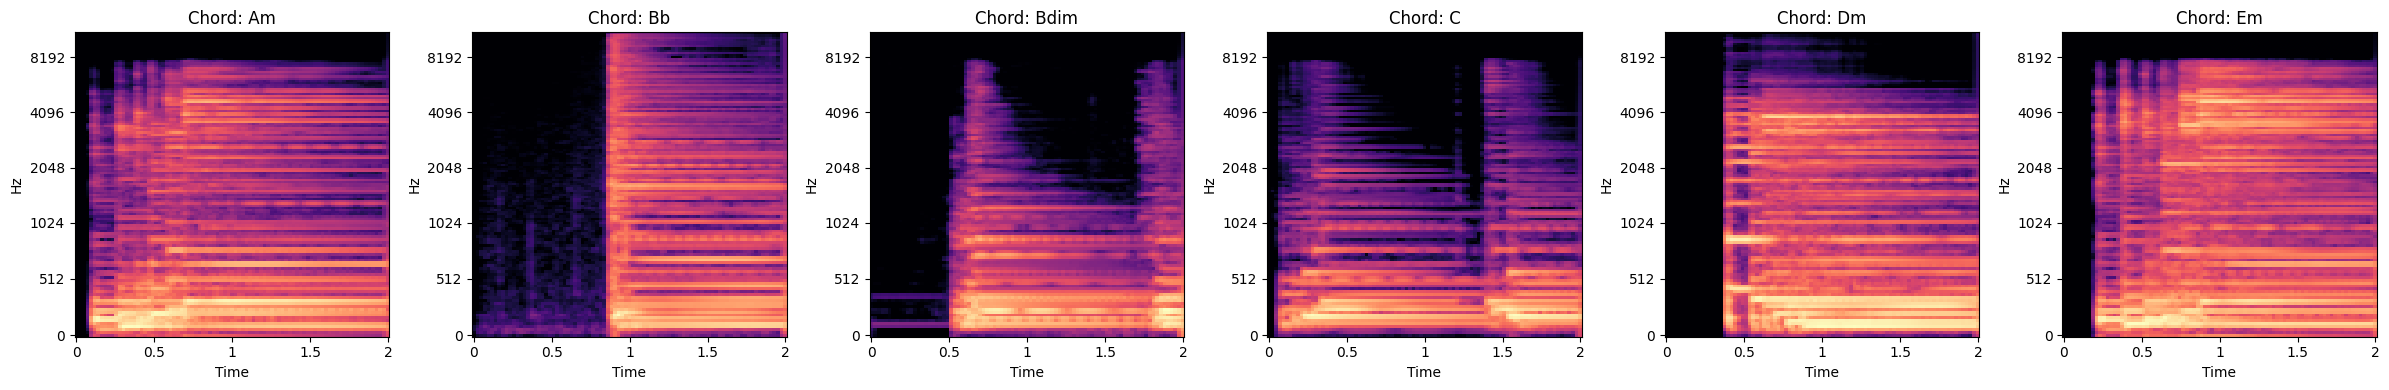

Spectrogram shape: (128, 87)  (n_mels x time_frames)


In [6]:
SAMPLE_RATE = 22050
DURATION = 2.0
N_MELS = 128
N_FFT = 2048
HOP_LENGTH = 512

def audio_to_melspec(file_path):
    y, sr = librosa.load(file_path, sr=SAMPLE_RATE, duration=DURATION)
    target_length = int(SAMPLE_RATE * DURATION)
    if len(y) < target_length:
        y = np.pad(y, (0, target_length - len(y)))
    mel = librosa.feature.melspectrogram(
        y=y, sr=sr, n_fft=N_FFT, hop_length=HOP_LENGTH, n_mels=N_MELS
    )
    mel_db = librosa.power_to_db(mel, ref=np.max)
    mel_db = (mel_db - mel_db.min()) / (mel_db.max() - mel_db.min() + 1e-8)
    return mel_db.astype(np.float32)

# Visualize one sample from each class
n_show = min(NUM_CLASSES, 6)
fig, axes = plt.subplots(1, n_show, figsize=(4*n_show, 4))
if n_show == 1:
    axes = [axes]
for ax, cls in zip(axes, CLASSES[:n_show]):
    sample = class_files[cls][0]
    mel = audio_to_melspec(sample)
    librosa.display.specshow(mel, sr=SAMPLE_RATE, hop_length=HOP_LENGTH,
                              x_axis='time', y_axis='mel', ax=ax)
    ax.set_title(f'Chord: {cls}')
plt.tight_layout()
plt.show()

print(f'Spectrogram shape: {mel.shape}  (n_mels x time_frames)')

## 6. PyTorch Dataset and DataLoader

In [7]:
class ChordDataset(Dataset):
    def __init__(self, file_list, labels):
        self.file_list = file_list
        self.labels = labels

    def __len__(self):
        return len(self.file_list)

    def __getitem__(self, idx):
        mel = audio_to_melspec(self.file_list[idx])
        mel = torch.tensor(mel).unsqueeze(0)  # (1, n_mels, time)
        return mel, self.labels[idx]

# Build the full file/label lists
all_files = []
all_labels = []
for cls, paths in class_files.items():
    for p in paths:
        all_files.append(p)
        all_labels.append(class_to_idx[cls])

dataset = ChordDataset(all_files, all_labels)

# 80/20 train/val split
train_size = int(0.8 * len(dataset))
val_size = len(dataset) - train_size
train_ds, val_ds = random_split(
    dataset, [train_size, val_size],
    generator=torch.Generator().manual_seed(SEED)
)
print(f'Train: {len(train_ds)} | Validation: {len(val_ds)}')

BATCH_SIZE = 32
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

Train: 1408 | Validation: 352


## 7. CNN architecture

3 convolutional blocks (Conv -> BN -> ReLU -> MaxPool) + 2 fully-connected layers with dropout.

In [8]:
class ChordCNN(nn.Module):
    def __init__(self, num_classes, input_shape):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 32, 3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, 3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, 3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2),
        )
        with torch.no_grad():
            dummy = torch.zeros(1, 1, *input_shape)
            flat_size = self.features(dummy).flatten(1).shape[1]
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(flat_size, 256),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(256, num_classes),
        )

    def forward(self, x):
        return self.classifier(self.features(x))

sample_mel = audio_to_melspec(all_files[0])
input_shape = sample_mel.shape
model = ChordCNN(NUM_CLASSES, input_shape).to(device)

print(model)
print(f'\nTotal parameters: {sum(p.numel() for p in model.parameters()):,}')

ChordCNN(
  (features): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
    (11): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=20480, out_features=256, bias=True)
    (2): ReLU()
    (3): Dropou

## 8. Training

In [9]:
EPOCHS = 20
LR = 1e-3

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=LR)

history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}

def run_epoch(loader, train=True):
    model.train() if train else model.eval()
    total_loss, correct, total = 0.0, 0, 0
    with torch.set_grad_enabled(train):
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            if train:
                optimizer.zero_grad()
            out = model(x)
            loss = criterion(out, y)
            if train:
                loss.backward()
                optimizer.step()
            total_loss += loss.item() * x.size(0)
            correct += (out.argmax(1) == y).sum().item()
            total += y.size(0)
    return total_loss / total, correct / total

best_val_acc = 0.0
for epoch in range(1, EPOCHS + 1):
    tr_loss, tr_acc = run_epoch(train_loader, train=True)
    val_loss, val_acc = run_epoch(val_loader, train=False)
    history['train_loss'].append(tr_loss)
    history['train_acc'].append(tr_acc)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)

    marker = ''
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), 'best_model.pth')
        marker = '  <- new best'

    print(f'Epoch {epoch:02d}/{EPOCHS} | '
          f'train loss {tr_loss:.4f} acc {tr_acc:.3f} | '
          f'val loss {val_loss:.4f} acc {val_acc:.3f}{marker}')

print(f'\nBest validation accuracy: {best_val_acc:.3f}')

Epoch 01/20 | train loss 3.4741 acc 0.158 | val loss 2.0512 acc 0.131  <- new best
Epoch 02/20 | train loss 1.8936 acc 0.221 | val loss 1.7003 acc 0.287  <- new best
Epoch 03/20 | train loss 1.5817 acc 0.327 | val loss 1.1879 acc 0.631  <- new best
Epoch 04/20 | train loss 1.3076 acc 0.397 | val loss 0.7821 acc 0.767  <- new best
Epoch 05/20 | train loss 1.1500 acc 0.479 | val loss 0.5535 acc 0.884  <- new best
Epoch 06/20 | train loss 1.0439 acc 0.521 | val loss 0.4167 acc 0.946  <- new best
Epoch 07/20 | train loss 0.9760 acc 0.536 | val loss 0.3518 acc 0.938
Epoch 08/20 | train loss 0.9724 acc 0.543 | val loss 0.3693 acc 0.932
Epoch 09/20 | train loss 0.9891 acc 0.542 | val loss 0.3754 acc 0.918
Epoch 10/20 | train loss 0.9095 acc 0.572 | val loss 0.2628 acc 0.963  <- new best
Epoch 11/20 | train loss 0.9097 acc 0.569 | val loss 0.3044 acc 0.966  <- new best
Epoch 12/20 | train loss 0.8657 acc 0.583 | val loss 0.2504 acc 0.966
Epoch 13/20 | train loss 0.8691 acc 0.583 | val loss 0.2

## 9. Plots (loss and accuracy)

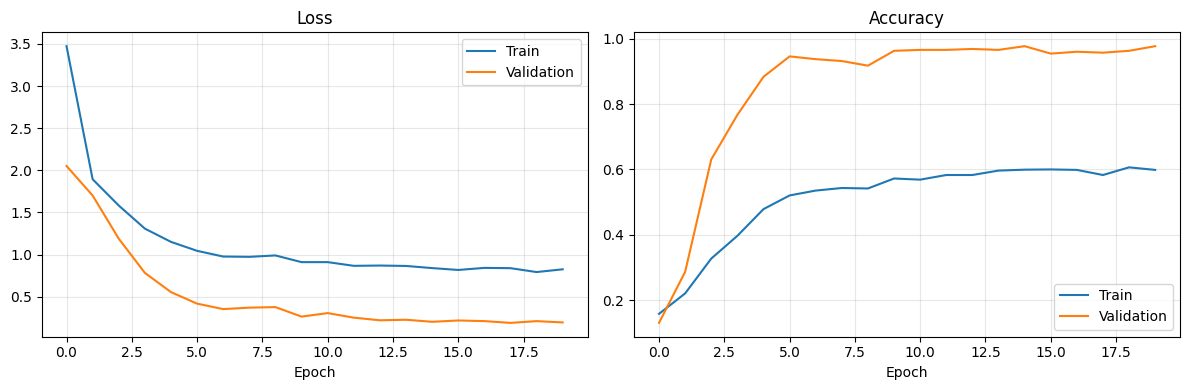

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(history['train_loss'], label='Train')
axes[0].plot(history['val_loss'], label='Validation')
axes[0].set_title('Loss')
axes[0].set_xlabel('Epoch')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(history['train_acc'], label='Train')
axes[1].plot(history['val_acc'], label='Validation')
axes[1].set_title('Accuracy')
axes[1].set_xlabel('Epoch')
axes[1].legend()
axes[1].grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 10. Evaluation — Confusion Matrix

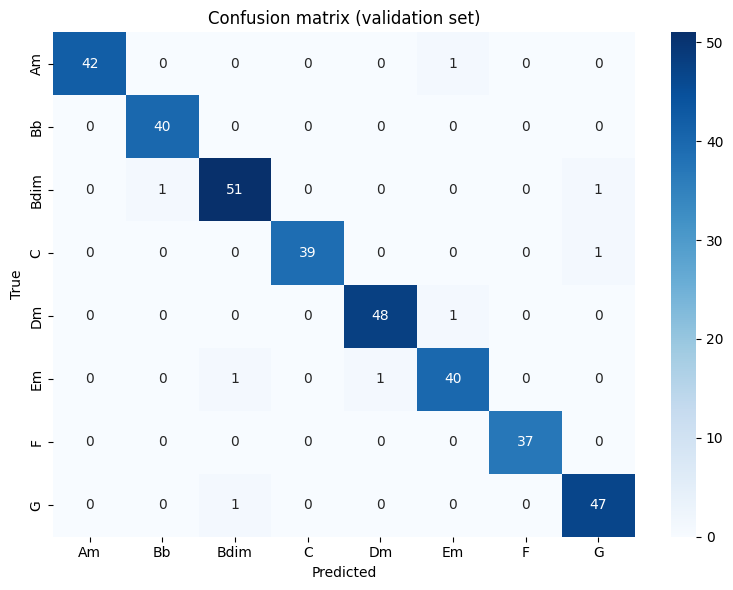

              precision    recall  f1-score   support

          Am       1.00      0.98      0.99        43
          Bb       0.98      1.00      0.99        40
        Bdim       0.96      0.96      0.96        53
           C       1.00      0.97      0.99        40
          Dm       0.98      0.98      0.98        49
          Em       0.95      0.95      0.95        42
           F       1.00      1.00      1.00        37
           G       0.96      0.98      0.97        48

    accuracy                           0.98       352
   macro avg       0.98      0.98      0.98       352
weighted avg       0.98      0.98      0.98       352



In [11]:
# Load the best checkpoint
model.load_state_dict(torch.load('best_model.pth'))
model.eval()

all_preds, all_labels_list = [], []
with torch.no_grad():
    for x, y in val_loader:
        x = x.to(device)
        preds = model(x).argmax(1).cpu().numpy()
        all_preds.extend(preds)
        all_labels_list.extend(y.numpy())

cm = confusion_matrix(all_labels_list, all_preds)
plt.figure(figsize=(max(8, NUM_CLASSES), max(6, NUM_CLASSES * 0.7)))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASSES, yticklabels=CLASSES)
plt.title('Confusion matrix (validation set)')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.tight_layout()
plt.show()

print(classification_report(all_labels_list, all_preds, target_names=CLASSES))

## 11. Inference — predict on a single file

In [12]:
def predict_chord(file_path):
    model.eval()
    mel = audio_to_melspec(file_path)
    x = torch.tensor(mel).unsqueeze(0).unsqueeze(0).to(device)
    with torch.no_grad():
        probs = torch.softmax(model(x), dim=1)[0].cpu().numpy()
    pred_idx = int(probs.argmax())
    return CLASSES[pred_idx], probs

# Test on a random validation sample
test_idx = random.choice(val_ds.indices)
test_file = all_files[test_idx]
true_label = CLASSES[all_labels[test_idx]]

pred, probs = predict_chord(test_file)
print(f'True chord:       {true_label}')
print(f'Predicted chord:  {pred}  ({"CORRECT" if pred == true_label else "WRONG"})')
print('\nTop 3 probabilities:')
for i in np.argsort(probs)[::-1][:3]:
    print(f'  {CLASSES[i]:<6} {probs[i]*100:5.1f}%')

True chord:       G
Predicted chord:  G  (CORRECT)

Top 3 probabilities:
  G       50.2%
  Bdim    48.1%
  Bb       0.8%


## 12. Save the model (for use in the application)

In [13]:
checkpoint = {
    'model_state_dict': model.state_dict(),
    'classes': CLASSES,
    'input_shape': list(input_shape),
    'sample_rate': SAMPLE_RATE,
    'duration': DURATION,
    'n_mels': N_MELS,
    'n_fft': N_FFT,
    'hop_length': HOP_LENGTH,
}
torch.save(checkpoint, 'chord_cnn.pth')
print('Model saved to chord_cnn.pth')

# Download locally
from google.colab import files
files.download('chord_cnn.pth')

Model saved to chord_cnn.pth


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## 13. (Bonus) Test on your own audio

In [14]:
from google.colab import files
print('Upload a WAV/MP3 file of a guitar chord:')
uploaded = files.upload()

for fname in uploaded.keys():
    pred, probs = predict_chord(fname)
    print(f'\nFile: {fname}')
    print(f'Predicted chord: {pred}')
    print('Top 3:')
    for i in np.argsort(probs)[::-1][:3]:
        print(f'  {CLASSES[i]:<6} {probs[i]*100:5.1f}%')

Upload a WAV/MP3 file of a guitar chord:
